# Example 29.1: Simulating the Huxley model

In this example, we will implement the analytical solutions to A.F. Huxley's 1957 sliding filament model.

By applying continuity constraints ($n(0^-) = n(0^+)$ and $n(h^-) = n(h^+)$), the piecewise differential equation for the crossbridge probability $n(x)$ can be solved analytically.

Let us define the grouped parameters $\phi = \frac{h}{S}(f_1 + g_1)$ and $V_{\mathrm{norm}} = \frac{2v}{S}$, where $S$ is the sarcomere length and $V_{\mathrm{norm}}$ is the normalized sliding velocity.

The analytical solutions for the three spatial regions are:

$$
x < 0: \quad n(x) = \frac{f_1}{f_1 + g_1} \left(1 - \exp\left(-\frac{\phi}{V_{\mathrm{norm}}}\right)\right) \exp\left(\frac{2 g_2 x}{S V_{\mathrm{norm}}}\right)
$$

$$
0 \le x \le h: \quad n(x) = \frac{f_1}{f_1 + g_1} \left(1 - \exp\left[\left(\frac{x^2}{h^2} - 1\right) \frac{\phi}{V_{\mathrm{norm}}}\right]\right)
$$

$$
x > h: \quad n(x) = 0
$$


## The spatial probability distribution

Using the equations above, we will plot the probability of a crossbridge being attached as a function of its physical displacement $x$.

Rather than using slow Python `for` or `while` loops to evaluate the piecewise conditions, we will use **NumPy boolean masking**. This allows us to apply the mathematical formulas to entire slices of the spatial array instantly.


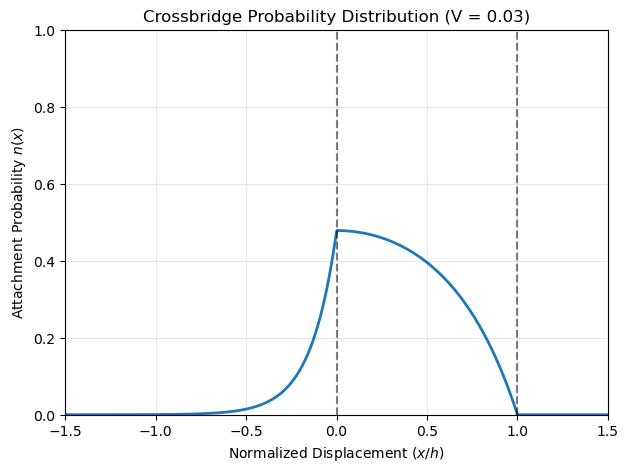

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Set the physical parameters
S = 2e-3  # Sarcomere length (mm)
f1 = 4.333  # Peak attachment rate (1/sec)
g1 = 1.00  # Detachment rate during pull (1/sec)
g2 = 20.91  # Rapid detachment rate past equilibrium (1/sec)
h = 1e-5  # Maximum reach of the crossbridge (mm)
l = 3e-5  # Distance between actin binding sites (mm)
k_spring = 10.00  # Crossbridge spring constant (dyne/mm)

V_norm = 0.03  # Normalized sliding velocity (half-sarcomeres / sec)

# Grouped parameter phi
phi = (h / S) * (f1 + g1)

# 2. Create the spatial grid
# We want to evaluate x from -1.5h to +1.5h
x = np.linspace(-1.5 * h, 1.5 * h, 1000)

# Initialize the probability array with zeros
n = np.zeros_like(x)

# 3. Vectorized piecewise evaluation using boolean masks!
# Region 1: x < 0
mask_neg = x < 0
n[mask_neg] = (
    (f1 / (f1 + g1))
    * (1 - np.exp(-phi / V_norm))
    * np.exp(g2 * x[mask_neg] / (S * V_norm / 2))
)

# Region 2: 0 <= x <= h
mask_pos = (x >= 0) & (x <= h)
n[mask_pos] = (f1 / (f1 + g1)) * (
    1 - np.exp(((x[mask_pos] ** 2 / h**2) - 1) * (phi / V_norm))
)

# Region 3: x > h is already zero by default!

# 4. Plot the probability distribution
plt.figure(figsize=(7, 5))
plt.plot(x / h, n, color="C0", linewidth=2)
plt.axvline(0, color="k", linestyle="--", alpha=0.5)
plt.axvline(1, color="k", linestyle="--", alpha=0.5)

plt.xlabel("Normalized Displacement ($x/h$)")
plt.ylabel("Attachment Probability $n(x)$")
plt.title(f"Crossbridge Probability Distribution (V = {V_norm})")
plt.xlim(-1.5, 1.5)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

**Observe:** When the muscle is contracting (sliding forward), the highest probability of finding an attached crossbridge is right around $x = 0$. Very few crossbridges manage to stay attached when $x < 0$ because $g_2$ forcefully rips them off to prevent them from acting as a mechanical brake.


## Generating macroscopic force

We have calculated the probability of a crossbridge being attached. But how much physical force does the whole muscle produce?

Huxley modeled the crossbridge as a simple linear spring. The force generated by a single attached crossbridge is:

$$
F_{\mathrm{XB}} = k x
$$

To find the expected value of the total tension $\langle T \rangle$ produced by the entire population of crossbridges, we simply integrate the force of a single crossbridge multiplied by the probability that it is actually attached!

$$
\langle T \rangle = \int_{-l/2}^{l/2} \frac{k x}{l} n(x) \, \mathrm{d}x
$$

By analytically substituting our piecewise $n(x)$ equations into this integral, we arrive at the exact macroscopic force produced by the muscle at a specific velocity $V_{\mathrm{norm}}$:

$$
\langle T \rangle = \frac{f_1}{f_1 + g_1} \frac{k h^2}{2l} \left(1 - \frac{V_{\mathrm{norm}}}{\phi} \left(1 - \exp\left(-\frac{\phi}{V_{\mathrm{norm}}}\right)\right)\right) \left(1 + \frac{1}{2} \left(\frac{f_1 + g_1}{g_2}\right)^2 \frac{V_{\mathrm{norm}}}{\phi}\right)
$$

If the muscle is held completely still ($V_{\mathrm{norm}} = 0$), we get the maximum isometric tension $T_{\mathrm{max}}$:

$$
T_{\mathrm{max}} = \frac{f_1}{f_1 + g_1} \frac{k h^2}{2l}
$$

Let us plot the normalized Force-Velocity curve (Tension/Tmax vs. Velocity).


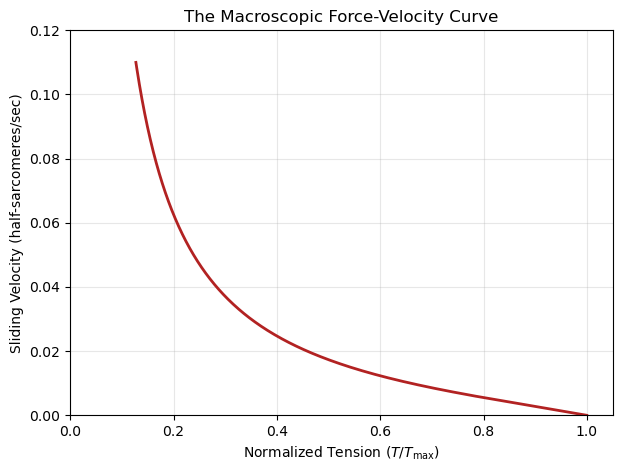

In [2]:
# 1. Create an array of sliding velocities
# Note: We start slightly above 0 to avoid division by zero in our formula!
V_vector = np.linspace(1e-5, 0.11, 500)

# 2. Calculate the normalized tension analytically
term1 = 1 - (V_vector / phi) * (1 - np.exp(-phi / V_vector))
term2 = 1 + (0.5 * ((f1 + g1) / g2) ** 2) * (V_vector / phi)

# Because we divided out T_max, the leading constants perfectly cancel out!
T_normalized = term1 * term2

# 3. Plot the Force-Velocity relationship
plt.figure(figsize=(7, 5))
plt.plot(T_normalized, V_vector, color="firebrick", linewidth=2)

plt.xlabel(r"Normalized Tension ($T / T_{\mathrm{max}}$)")
plt.ylabel("Sliding Velocity (half-sarcomeres/sec)")
plt.title("The Macroscopic Force-Velocity Curve")
plt.xlim(0, 1.05)
plt.ylim(0, 0.12)
plt.grid(alpha=0.3)
plt.show()

**Conclusion:** By making a few brilliant assumptions about the microscopic probabilities of a single myosin head attaching to actin, Huxley's 1957 model mathematically derives the exact hyperbolic macroscopic Force-Velocity curve observed in whole muscle tissue.
